# 📈 Apple Stock Market Analysis & Prediction

## Real-World Finance Data Project

**Author:** Poojan Javiya

This project focuses on analyzing historical Apple stock market data and building a machine learning model to predict stock closing prices using financial indicators and time-series analysis techniques.


## Loading the Dataset

The dataset contains historical Apple stock market data including opening price, closing price, highest price, lowest price, trading volume, and other market-related information.

The data is used for exploratory analysis, feature engineering, and predictive modeling.

In [1]:
import pandas as pd

df = pd.read_csv('apple_stock.csv')

## Dataset Overview

The dataset includes historical daily stock market records with the following features:

- Open Price
- High Price
- Low Price
- Close Price
- Trading Volume
- Open Interest

The dataset spans multiple years of Apple stock market activity, making it suitable for time-series analysis and financial prediction tasks.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     8364 non-null   str    
 1   Open     8364 non-null   float64
 2   High     8364 non-null   float64
 3   Low      8364 non-null   float64
 4   Close    8364 non-null   float64
 5   Volume   8364 non-null   int64  
 6   OpenInt  8364 non-null   int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 457.5 KB


In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


## Date Preprocessing

The `Date` column was converted into datetime format to enable proper time-series analysis and visualization.

The date column was then set as the dataframe index to simplify chronological analysis of stock trends.

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df.set_index('Date', inplace=True)

## Exploratory Data Analysis

Visualizations were created to analyze:
- Historical stock price trends
- Moving averages
- Daily return distribution
- Market volatility

These analyses help identify long-term growth patterns and stock behavior over time.

In [10]:
from matplotlib import pyplot as plt
import seaborn as sns

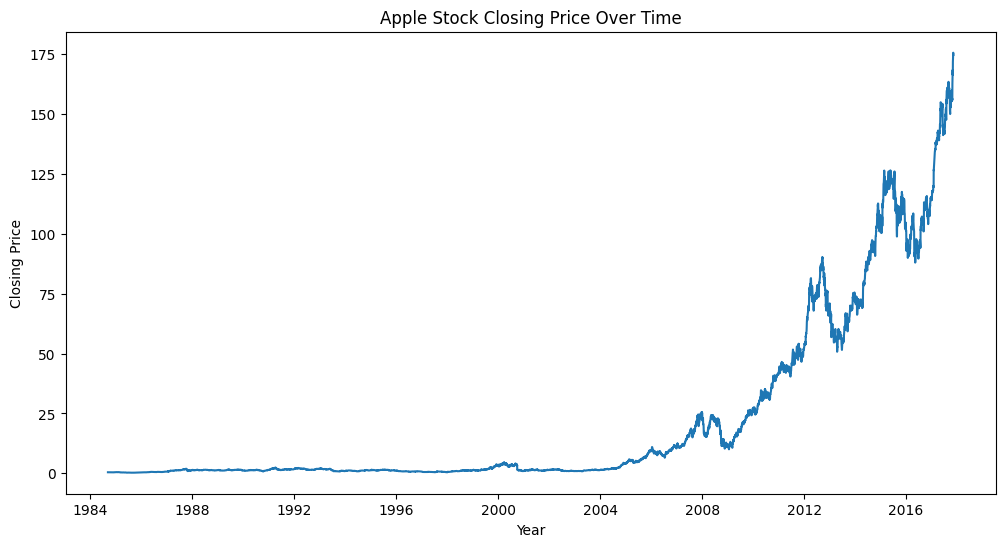

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'])

plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Year")
plt.ylabel("Closing Price")

plt.show()

## Feature Engineering

To better capture stock market trends, 30-day and 100-day moving averages were calculated. Daily returns were also generated to analyze stock price volatility and market behavior.

In [12]:
df['MA_30'] = df['Close'].rolling(window=30).mean()

df['MA_100'] = df['Close'].rolling(window=100).mean()

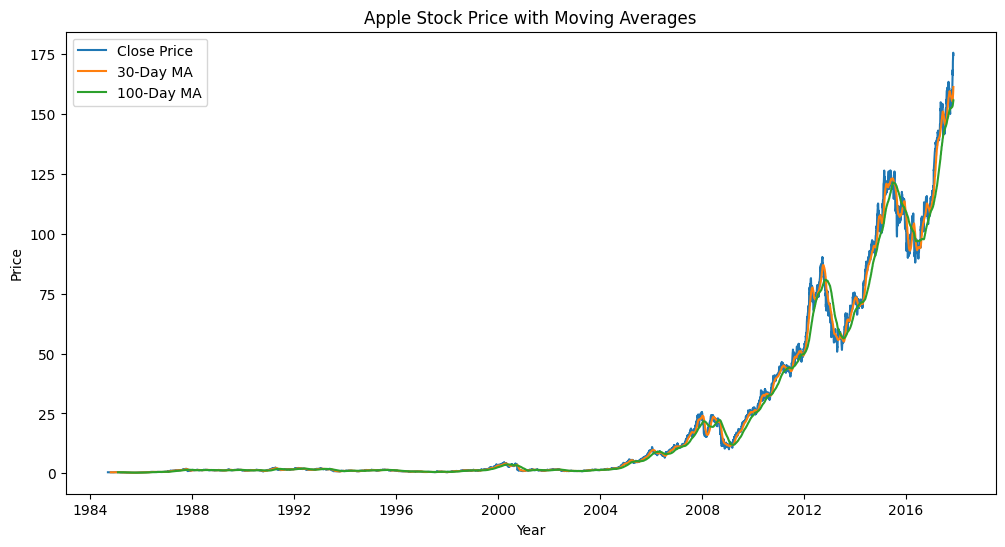

In [13]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Close Price')

plt.plot(df.index, df['MA_30'], label='30-Day MA')

plt.plot(df.index, df['MA_100'], label='100-Day MA')

plt.title("Apple Stock Price with Moving Averages")

plt.xlabel("Year")
plt.ylabel("Price")

plt.legend()

plt.show()

In [14]:
df['Daily_Return'] = df['Close'].pct_change()

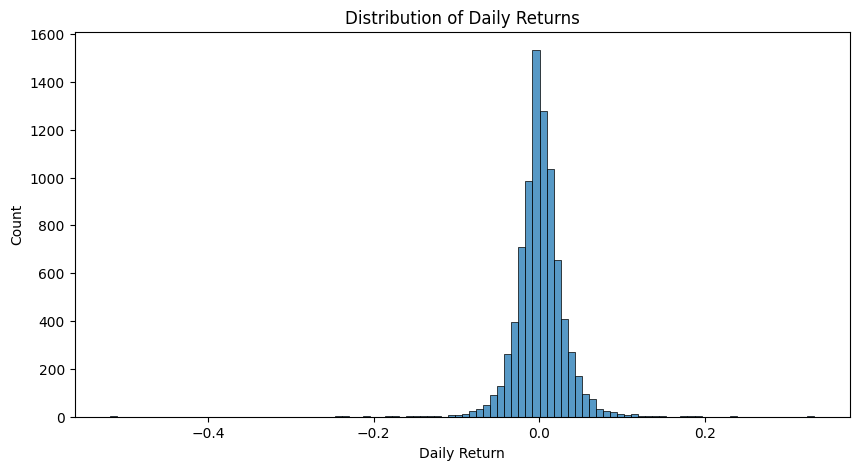

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['Daily_Return'].dropna(), bins=100)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.show()

## Machine Learning Model

A Linear Regression model was trained to predict future Apple stock closing prices using features such as:
- Open Price
- High Price
- Low Price
- Volume
- Moving Averages

The dataset was split chronologically to preserve time-series order during training and testing.

In [38]:
df['Next_Close'] = df['Close'].shift(-1)

In [39]:
df.dropna(inplace=True)

In [40]:
X = df[['Open', 'High', 'Low', 'Volume', 'MA_30', 'MA_100']]

y = df['Next_Close']

In [41]:
df.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
OpenInt         0
MA_30           0
MA_100          0
Daily_Return    0
Next_Close      0
dtype: int64

In [42]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
y_pred = model.predict(X_test)

## Model Evaluation

The model was evaluated using regression metrics including:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model achieved strong predictive performance, indicating that historical financial indicators are highly associated with stock closing prices.

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.0320278827127158
RMSE: 1.4559757893633545
R² Score: 0.9978033348077355


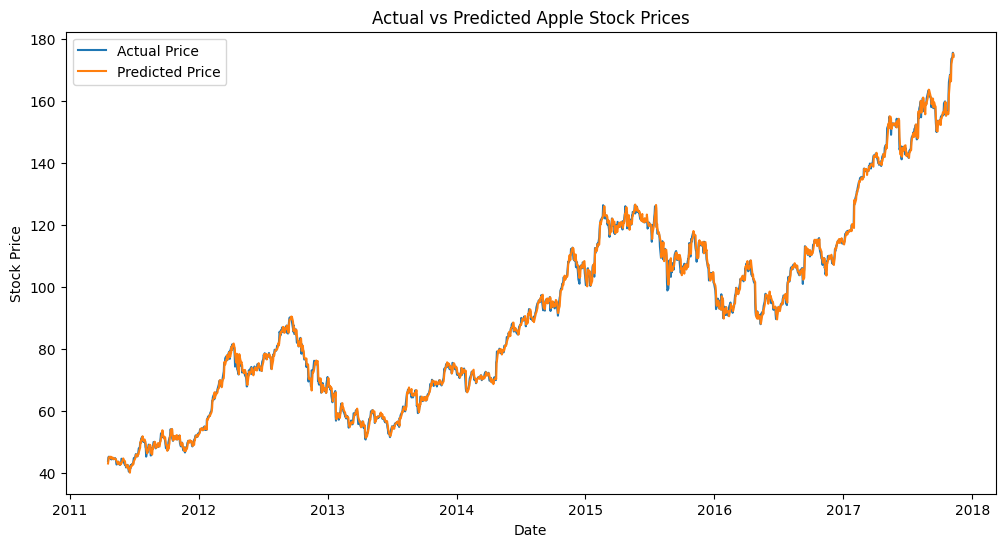

In [46]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label='Actual Price')

plt.plot(y_test.index, y_pred, label='Predicted Price')

plt.title("Actual vs Predicted Apple Stock Prices")

plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

## Conclusion

This project successfully implemented a real-world financial data analysis and machine learning workflow using historical Apple stock market data.

The project combined:
- Time-series analysis
- Financial visualization
- Feature engineering
- Moving average analysis
- Daily return analysis
- Machine learning regression

The Linear Regression model demonstrated strong predictive performance in estimating future stock closing prices using historical financial indicators.

Overall, the project highlights how data science and machine learning techniques can be applied to financial market analysis and predictive modeling.